# Compulsory Assignment 2: Convolutional neural networks

Please fill out the group name, number, members and optionally the name below.

**Group number**: 20\
**Group member 1**: Oskar Støre\
**Group member 2**: Magnus Lundetræ Fidje\
**Group member 3**: Håkon Skramstad\
**Group name (optional)**: 


# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. The assignment is submitted by handing in this notebook as an .ipynb file and as a .pdf file. 


# Introduction 
This assignment will start with classifying handwritten digits from the MNIST dataset, used in the voluntary assignment and the first compulsory assignment. The second part of this task will revolve around classifying the open-source Fashion-MNIST.



## Fashion-MNIST

The Fashion-MNIST is a dataset created from Zalando's article images(https://github.com/zalandoresearch/fashion-mnist/blob/master/README.md). The dataset consists of 70,000 labels images in 28x28 grayscale image labeled from 0 to 10. The goal of the Fashion-MNIST to work as a harder version of the handletter dataset MNIST. The Github repo for the dataset describe the dataset to be:
- "intend Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms."


<center><img src="fashion-mnist-sprite.png" width="500" height="400"></center>


# LeNet-5 Architecture Overview

**LeNet-5** (LeCun et al., 1998) is a foundational Convolutional Neural Network (CNN) designed for handwritten digit classification (MNIST). It established the classic deep learning workflow: alternating **Convolution** and **Pooling** layers to extract spatial features, followed by **Dense** layers for classification.

---

## 1. Network Pipeline

$$\text{Input Image} \longrightarrow \text{Conv1} \longrightarrow \text{Pool1} \longrightarrow \text{Conv2} \longrightarrow \text{Pool2} \longrightarrow \text{Flatten} \longrightarrow \text{FC1} \longrightarrow \text{FC2} \longrightarrow \text{Output}$$

---

## 2. Layer Specification Table

| Layer | Type | Configuration / Parameters | Activation |
| :--- | :--- | :--- | :--- |
| **C1** | Conv2D | 6 filters ($5 \times 5$), Padding='same' | `tanh` |
| **S2** | AvgPooling | Window: $2 \times 2$, Stride: 2 | — |
| **C3** | Conv2D | 16 filters ($5 \times 5$), Padding='valid' | `tanh` |
| **S4** | AvgPooling | Window: $2 \times 2$, Stride: 2 | — |
| **Flatten** | Reshape | Converts feature maps to 1D vector | — |
| **F5** | Dense | 120 neurons | `tanh` |
| **F6** | Dense | 84 neurons | `tanh` |
| **Output** | Dense | 10 neurons (Classes 0–9) | `softmax` |

---

## 3. Key Concepts for Students

* **Hierarchical Feature Extraction:** Early layers extract simple visual features (edges and lines), while deeper layers combine them into complex shapes (loops and intersections).
* **Spatial Invariance:** Subsampling (Pooling) reduces feature map resolution, making the model resilient to minor shifts or rotations in input images.
* **Evolution to Modern CNNs:**
  * **Activations:** Replaced historical `tanh` with `ReLU` to eliminate vanishing gradients.
  * **Pooling:** Replaced `AveragePooling` with `MaxPooling` for stronger feature selection.
  * **Normalization:** Added `BatchNorm` after convolution operations to accelerate convergence and stabilize training.
## Assignment structure

1. Part 1: Implementing LeNet for classifying MNIST.
2. Part 2: Designing your own CNN for classifying Fashion-MNIST
 

```python
prediction = model.predict(X_test)
flat_prediction = np.argmax(prediction, axis=1) # Flatten softmax predictions
submissionDF = pd.DataFrame()
submissionDF['ID'] = range(len(flat_prediction)) # The submission csv file must have an row index column called 'ID'
submissionDF['Prediction'] = flat_prediction
submissionDF.to_csv('submission.csv', index=False) # Remember to store the dataframe to csv without the nameless index column.
```

## Library imports

In [130]:
# Feel free to add or remove libraries as you want
import time

import numpy as np
import pandas as pd
import h5py

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow.keras as ks

SEED = 458
RNG = np.random.default_rng(SEED) # Random number generator

from utilities import *

import tensorflow as tf

# import f1-score
f1score = ks.metrics.F1Score(average='macro', name='f1_score')

# import confusion matrix
from sklearn.metrics import confusion_matrix

import seaborn as sns

# Part 1: CNN for classifying the MNIST dataset

## Loading MNIST

In [131]:
datasets = load_mnist(verbose=0)
X_train, y_train = datasets['X_train'], datasets['y_train']
X_val,   y_val   = datasets['X_val'],   datasets['y_val']
X_test,  y_test  = datasets['X_test'],  datasets['y_test']

X_train = np.concatenate([X_train, X_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0).astype('int32')

del datasets, X_val, y_val # Good to reduce uneccesary RAM usage

## Preprocessing

In [132]:
# Reshape data to account for color channel
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Normalizing input between [0,1]
X_train = X_train.astype("float32")/np.max(X_train)
X_test  = X_test.astype("float32")/np.max(X_test)

# Converting targets from numbers to categorical format
y_train = ks.utils.to_categorical(y_train, len(np.unique(y_train)))
y_test  = ks.utils.to_categorical(y_test, len(np.unique(y_test)))

## Task 1.1: Build a CNN network with the LeNet5 architecture

##### Implement LeNet5 architecture according to the previous specifications: 

--------------------------


##### Compile the network with the
* `tf.keras.losses.CategoricalCrossentropy` loss function
* the `adam` optimizer 
* with the `accuracy` metric and (your own implementation of the) F1-score metric.

In [158]:
model = ks.Sequential()

model.add(ks.layers.Conv2D(
    filters=6, kernel_size=(5,5),
    padding='same', name='Conv1',
    activation='tanh'
))

model.add(ks.layers.AvgPool2D(
    pool_size =(2,2), strides =(2,2),
    name= 'Pool1'
))

model.add(ks.layers.Conv2D(
    filters=16, kernel_size=(5,5),
    padding='valid', name='Conv2',
    activation='tanh'
))

model.add(ks.layers.AvgPool2D(
    pool_size=(2,2), strides=(2,2),
    name='Pool2'
))

# flatten before giving to nn
model.add(ks.layers.Flatten())

model.add(ks.layers.Dense(
    units=120, name='FC1',
    activation='tanh'
))

model.add(ks.layers.Dense(
    units=84, name='FC2',
    activation='tanh'
))

model.add(ks.layers.Dense(
    units=10, name='Output',
    activation='softmax'
))

### Task 1.1.2 Train network

Train the network with a 
* batch size of 64 samples
* for 20 epochs
* 1/8 validation split

In [159]:
# don't need to specify batch size
model.build(input_shape=(None, 28, 28, 1))

model.compile(
    optimizer=ks.optimizers.Adam(learning_rate=0.001),
    loss= ks.losses.CategoricalCrossentropy(),
    metrics= ['accuracy', f1score]
)

model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (AveragePooling2D)        │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (AveragePooling2D)        │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [135]:
history = model.fit(X_train, y_train, batch_size=64, epochs=20, validation_split=1/8)

Epoch 1/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9121 - f1_score: 0.9109 - loss: 0.2931 - val_accuracy: 0.9539 - val_f1_score: 0.9531 - val_loss: 0.1492
Epoch 2/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9653 - f1_score: 0.9651 - loss: 0.1128 - val_accuracy: 0.9720 - val_f1_score: 0.9718 - val_loss: 0.0985
Epoch 3/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9766 - f1_score: 0.9765 - loss: 0.0751 - val_accuracy: 0.9764 - val_f1_score: 0.9761 - val_loss: 0.0770
Epoch 4/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9822 - f1_score: 0.9821 - loss: 0.0564 - val_accuracy: 0.9752 - val_f1_score: 0.9749 - val_loss: 0.0829
Epoch 5/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9859 - f1_score: 0.9858 - loss: 0.0453 - val_accuracy: 0.9804 - val_f1_score: 0.9802 - val_loss: 0.0667
Epoch 6/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9886 - f1_score: 0.9886 - loss: 0.0354 - val_accuracy: 0.9812 - val_f1_score: 0.9811

## Task 1.2 Evaluaiton
### Task 1.2.1 Plot training history and evaluate on test dataset

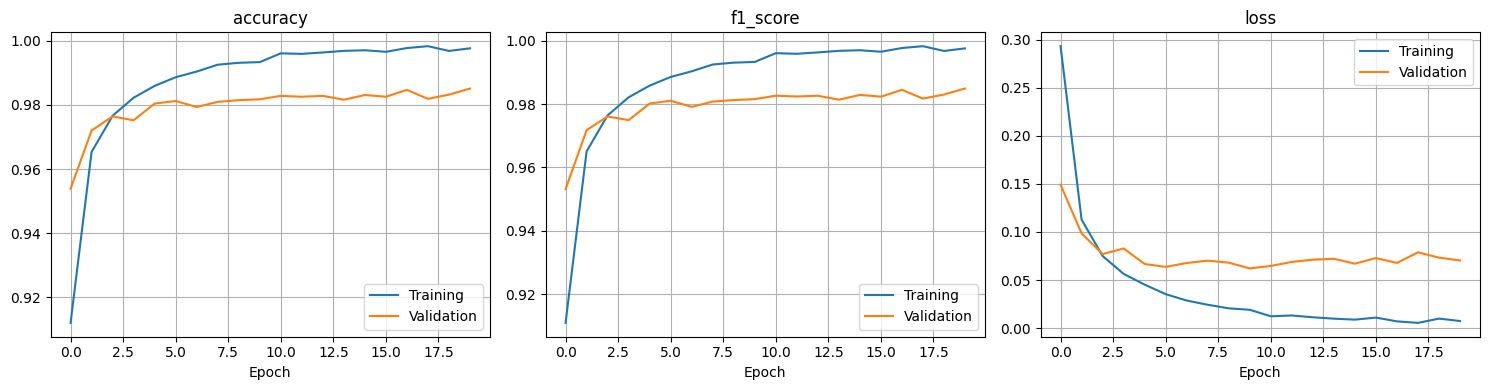

In [136]:
plot_training_history(history)

### Task 1.2.2 Evaluate on the test dataset

In [137]:
evaluate = model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9848 - f1_score: 0.9847 - loss: 0.0638


### Task 2.2.3 Create a confution matrix for both traing and testing data
- Does the test data and train data predikt the same items wrong?

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


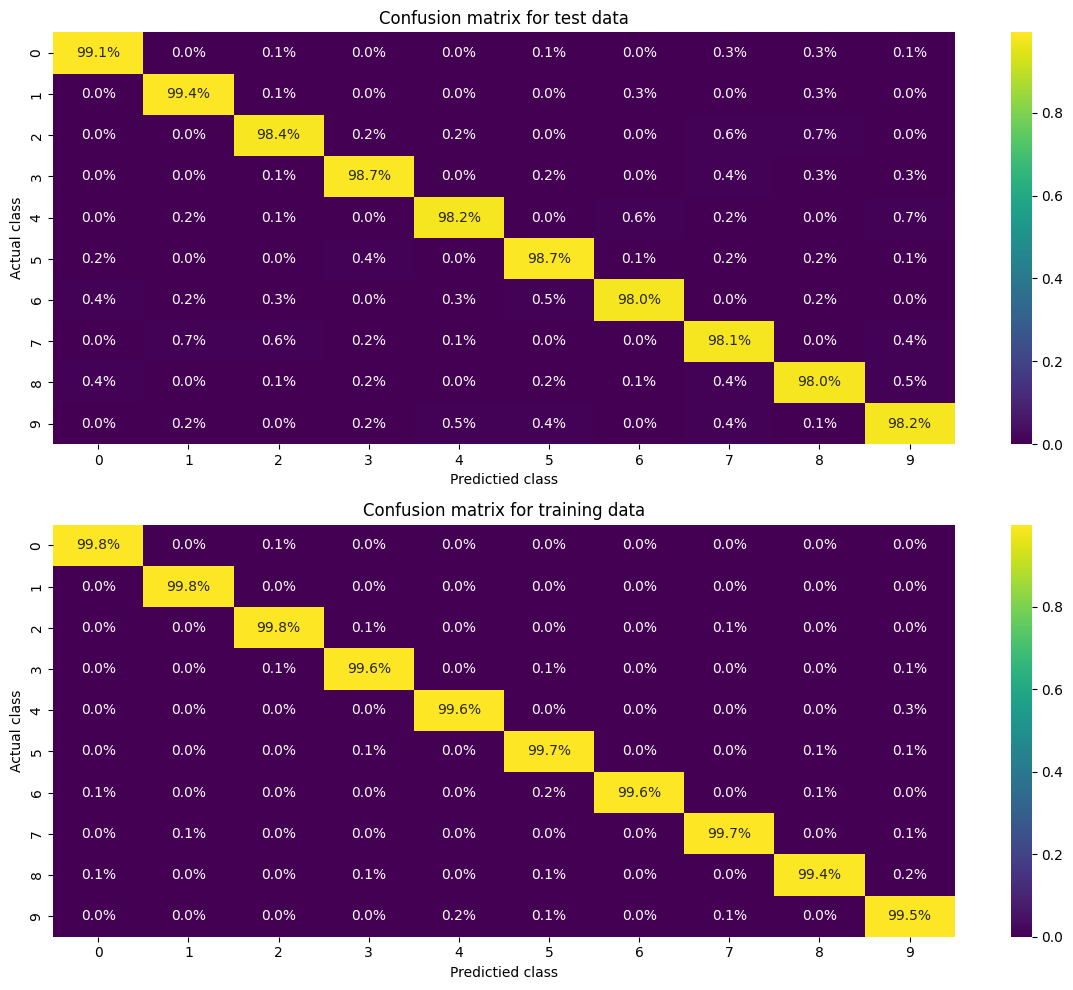

In [138]:
# creating confusion matrix for  test data
y_prob_test = model.predict(X_test)

# have to change to give one prediction for each picture
y_pred_test = np.argmax(y_prob_test,axis=1)
y_test_conf = np.argmax(y_test,axis=1)

cf_test = confusion_matrix(y_test_conf,y_pred_test, normalize='true')

# creating confusion matrix for training data
y_prob_train = model.predict(X_train)

# same as with test, changing to prediction
y_pred_train = np.argmax(y_prob_train, axis=1)
y_train_conf = np.argmax(y_train, axis=1)

cf_train = confusion_matrix(y_train_conf, y_pred_train, normalize='true')

# plotting
plt.figure(figsize=(12,10))

plt.subplot(2,1,1)
sns.heatmap(cf_test, annot=True, fmt='.1%', cmap='viridis')
plt.xlabel('Predictied class')
plt.ylabel('Actual class')
plt.title('Confusion matrix for test data')

plt.subplot(2,1,2)
sns.heatmap(cf_train, annot=True, fmt='.1%', cmap='viridis')
plt.xlabel('Predictied class')
plt.ylabel('Actual class')
plt.title('Confusion matrix for training data')

plt.tight_layout()

plt.show()

#### The training data and test data have both wery high accuracy, so it is not that easy to compare. From what we can see both training and test classify 9 as 4's (0.3% and 1.1%) somtimes wrong

## Task 2.3: MNIST discussion

**Task 2.3.1: What is overfitting and how does it occur during training of the LeNet-5 model**

**Task 2.3.2: What is ReLU and Leaky ReLU, what is their derivative and how does their derivative solve the vanishing gradient problem?**

**Task 2.3.3: Calculate the numbers of weight and the output shape for the LeNet-5 at each layer, Show calculation**

**Answer 2.3.1**: Overfitting is when the model is fitted to closely to the training data, it does not generalize godd. So when you test on new unseen data it gets worse results. In the LeNet-5 model we can see this happening after roughly two epochs, because this is when the training data results starts having better results than on the validation data. We se this from the plot of the training history.

**Answer 2.3.2**: ReLU and Leaky ReLU are two different activation functions. ReLU gives zero for negative input, and passes positive input thrugh. The derivative of the ReLU gives 0 if it is lees than zero and 1 if the input is over zero. That means for positive input the derivative is a constant 1 which prevents the gradient from shrinking and therfore solves the vanishing gradient problem during backprogopogation. The Leaky ReLU is the same as ReLU for positive inputs, but for the negative it gives a small negative slope. This means the derivative of Leaky ReLU gives 1 for positive input and it does let negative input "die", gives a constant small gradient for negatives. This ensures it the gradient dosen't vanish and it can still learn for negative values.

**Answer 2.3.3**: 

**Input:** $28 \times 28 \times 1$

---

### Conv1: Conv2D (6 filters, $5 \times 5$, padding = 'same')

- $n = 28$, $m = 5$, $s = 1$, $K = 6$, $C_{in} = 1$
- Padding 'same': $p = \frac{m-1}{2} = \frac{5-1}{2} = 2$

$$o = \left\lfloor \frac{28 + 2 \cdot 2 - 5}{1} \right\rfloor + 1 = 27 + 1 = 28$$

$$\text{params} = (5 \cdot 5 \cdot 1 + 1) \cdot 6 = 26 \cdot 6 = 156$$

**Output shape:** $28 \times 28 \times 6$, **Weights:** $156$

---

### Pool1: AvgPooling ($2 \times 2$, stride 2)

- $n = 28$, $m = 2$, $s = 2$

$$o = \left\lfloor \frac{28 - 2 }{2} \right\rfloor + 1 = 13 + 1 = 14$$

**Output shape:** $14 \times 14 \times 6$, **Weights:** $0$

---

### Conv2: Conv2D (16 filters, $5 \times 5$, padding = 'valid')

- $n = 14$, $m = 5$, $s = 1$, $K = 16$, $C_{in} = 6$
- Padding 'valid': $p = 0$

$$o = \left\lfloor \frac{14 + 2 \cdot 0 - 5}{1} \right\rfloor + 1 = 9 + 1 = 10$$

$$\text{params} = (5 \cdot 5 \cdot 6 + 1) \cdot 16 = 151 \cdot 16 = 2416$$

**Output shape:** $10 \times 10 \times 16$, **Weights:** $2416$

---

### Pool2: AvgPooling ($2 \times 2$, stride 2)

- $n = 10$, $m = 2$, $s = 2

$$o = \left\lfloor \frac{10 - 2}{2} \right\rfloor + 1 = 4 + 1 = 5$$

**Output shape:** $5 \times 5 \times 16$, **Weights:** $0$

---

### Flatten

$$5 \cdot 5 \cdot 16 = 400$$

**Output shape:** $400$, **Weights:** $0$

---

### FC1: Dense (120 neurons)

- $N_{in} = 400$, $N_{out} = 120$

$$\text{params} = (400 + 1) \cdot 120 = 48120$$

**Output shape:** $120$, **Weights:** $48120$

---

### FC2: Dense (84 neurons)

- $N_{in} = 120$, $N_{out} = 84$

$$\text{params} = (120 + 1) \cdot 84 = 10164$$

**Output shape:** $84$, **Weights:** $10164$

---

### Output: Dense (10 neurons)

- $N_{in} = 84$, $N_{out} = 10$

$$\text{params} = (84 + 1) \cdot 10 = 850$$

**Output shape:** $10$, **Weights:** $850$

# Task 2: CNN for classifying the Fashion-MNIST dataset

In this task you shall implement a CNN model, and train it to classify the images in the Fashion-MNIST dataset.

## Importing Fashion-MNIST

- Filename: `Fashion_MNIST.h5`

In [139]:
# Change this path
#path = r"C:\Users\alfa\OneDrive - Norwegian University of Life Sciences\Desktop\AML_NMBU\DAT300\DAT300_2025\CA2_CNN_Template-1\Template\Fashion_MNIST.h5"
path = r"/home/skramstad/Documents/DAT300/Assignments/CA2/Fashion_MNIST.h5"
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot" 
}

In [140]:
# 2. Use 'path' variable here
with h5py.File(path, 'r') as f:
    print('Datasets in file:', list(f.keys()))
    X_train = np.asarray(f['train_images'])
    y_train = np.asarray(f['train_labels'])
    X_test  = np.asarray(f['test_images'])
    print('Nr. train images: %i' % (X_train.shape[0]))
    print('Nr. test images: %i' % (X_test.shape[0]))

Datasets in file: ['test_images', 'train_images', 'train_labels']
Nr. train images: 59500
Nr. test images: 10500


## Task 2.1: Preprocess the data
Preprocess the data as you see fit

In [141]:
# printing to see shape first
print(f'X_train shape: {X_train.shape} \n' 
      f'X_test shape: {X_test.shape} \n'
      f'y_train shape: {y_train.shape}')

X_train shape: (59500, 28, 28) 
X_test shape: (10500, 28, 28) 
y_train shape: (59500,)


In [142]:
# adding a fourth dimension
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2], 1))

# vector to matrix
y_train = y_train[:, np.newaxis]

In [143]:
# normalize inputs from 0-255 to 0.0 - 1.0
X_train = X_train.astype("float32")/np.max(X_train)
X_test = X_test.astype("float32")/np.max(X_test)

In [144]:
# Converting targets from numbers to categorical format
y_train = ks.utils.to_categorical(y_train, len(np.unique(y_train)))

In [145]:
# printing to see if shapes are correct
print(f'X_train shape: {X_train.shape} \n' 
      f'X_test shape: {X_test.shape} \n'
      f'y_train shape: {y_train.shape}')

X_train shape: (59500, 28, 28, 1) 
X_test shape: (10500, 28, 28, 1) 
y_train shape: (59500, 10)


## Task 2.2: Visualize the dataset
Plot a few samples images and the distrbution of classes in the data. 

Text(0, 0.5, 'Count')

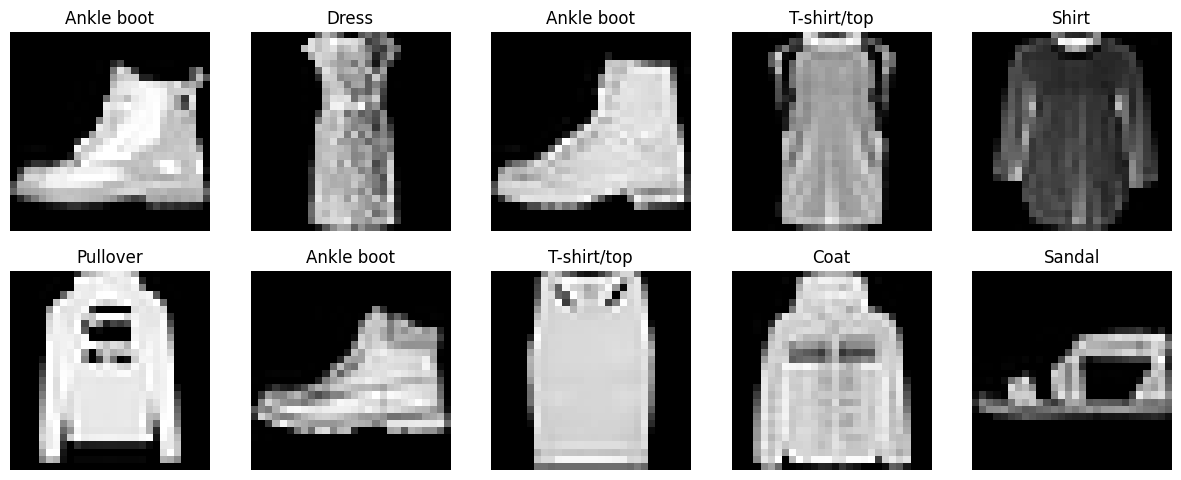

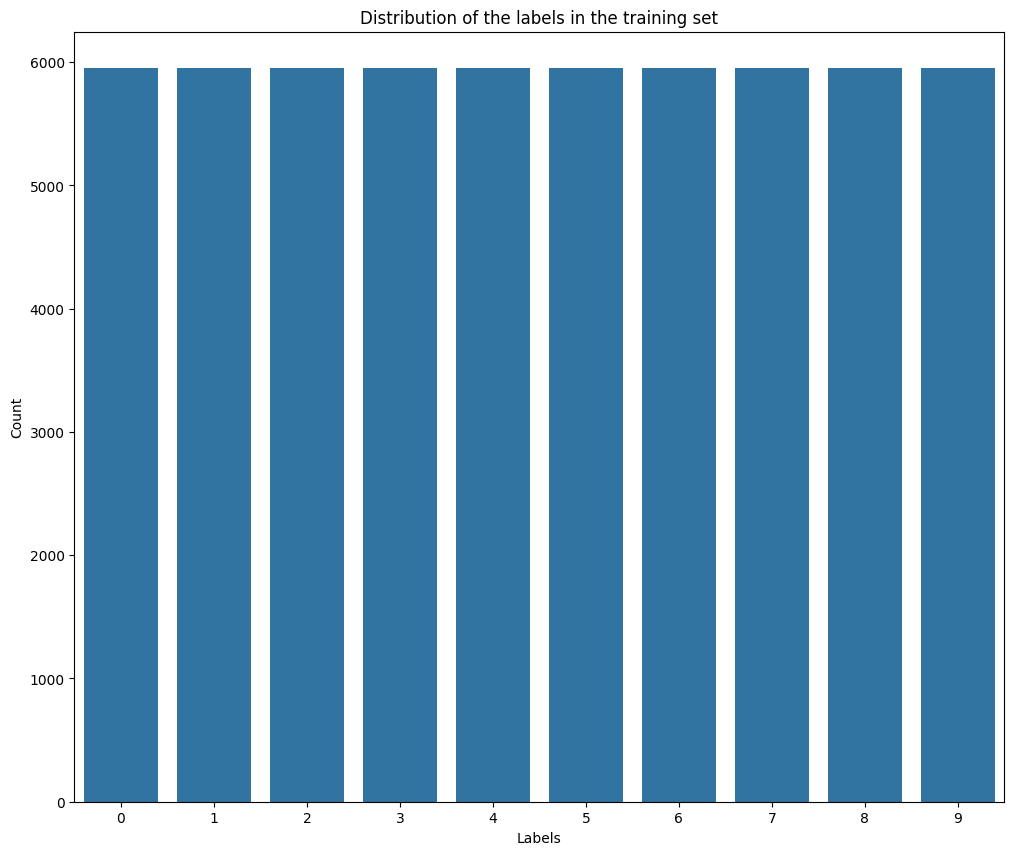

In [146]:
# ploting a few sample images
plt.figure(figsize=(15,15))

for i in range(10):
    plt.subplot(5,5, i+1)
    plt.imshow(X_train[i+1], cmap='gray')
    plt.title(labels[np.argmax(y_train[i+1])])
    plt.axis('off')


# ploting the distribution of the classes
plt.figure(figsize=(12,10))
sns.countplot(x=np.argmax(y_train,axis=1))
plt.title('Distribution of the labels in the training set')
plt.xlabel('Labels')
plt.ylabel('Count')

## Task 2.3: Build a CNN for classifying the Fashion-MNIST dataset
Build a CNN model 
- Experiment with different, Kernel sizes, stride, type/number of layers. 
- Don't overcomplicate and use it as grounds for discussion. 
- Tips, when you make changes to improve the model, save some earlier iterations.
- Only one model score higher than beat me.

## 2 conv and avg. pooling

In [147]:
# build the model
model_v1 = ks.Sequential()

model_v1.add(ks.layers.Conv2D(
    filters=6, kernel_size=(3,3),
    padding='same', name='Conv1',
    activation='relu'
))

model_v1.add(ks.layers.AvgPool2D(
    pool_size =(2,2), strides =(2,2),
    name= 'Pool1'
))

model_v1.add(ks.layers.Conv2D(
    filters=16, kernel_size=(3,3),
    padding='valid', name='Conv2',
    activation='relu'
))

model_v1.add(ks.layers.AvgPool2D(
    pool_size=(2,2), strides=(2,2),
    name='Pool2'
))

# flatten before giving to nn
model_v1.add(ks.layers.Flatten())

model_v1.add(ks.layers.Dense(
    units=1024, name='FC1',
    activation='relu'
))

model_v1.add(ks.layers.Dense(
    units=128, name='FC2',
    activation='relu'
))

model_v1.add(ks.layers.Dense(
    units=10, name='Output',
    activation='softmax'
))

# don't need to specify batch size
model_v1.build(input_shape=(None, 28, 28, 1))

model_v1.compile(
    optimizer=ks.optimizers.Adam(learning_rate= 0.001),
    loss= ks.losses.CategoricalCrossentropy(),
    metrics= ['accuracy', f1score]
)

model_v1.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 28, 28, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (AveragePooling2D)        │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 12, 12, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (AveragePooling2D)        │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 1024)           │       590,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 724,278 (2.76 MB)

 Trainable params: 724,278 (2.76 MB)

 Non-trainable params: 0 (0.00 B)

In [148]:
# trian the model
history_fashion_v1 = model_v1.fit(X_train, y_train, batch_size=64, epochs=10, validation_split=1/6)

Epoch 1/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8006 - f1_score: 0.8290 - loss: 0.5409 - val_accuracy: 0.8620 - val_f1_score: 0.8597 - val_loss: 0.3850
Epoch 2/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8672 - f1_score: 0.8662 - loss: 0.3638 - val_accuracy: 0.8740 - val_f1_score: 0.8689 - val_loss: 0.3403
Epoch 3/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8839 - f1_score: 0.8833 - loss: 0.3131 - val_accuracy: 0.8778 - val_f1_score: 0.8776 - val_loss: 0.3393
Epoch 4/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8971 - f1_score: 0.8967 - loss: 0.2804 - val_accuracy: 0.8834 - val_f1_score: 0.8771 - val_loss: 0.3070
Epoch 5/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9056 - f1_score: 0.9052 - loss: 0.2568 - val_accuracy: 0.8978 - val_f1_score: 0.8979 - val_loss: 0.2757
Epoch 6/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9135 - f1_score: 0.9132 - loss: 0.2349 - val_accuracy: 0.9039 - val_f1_score: 0.9026

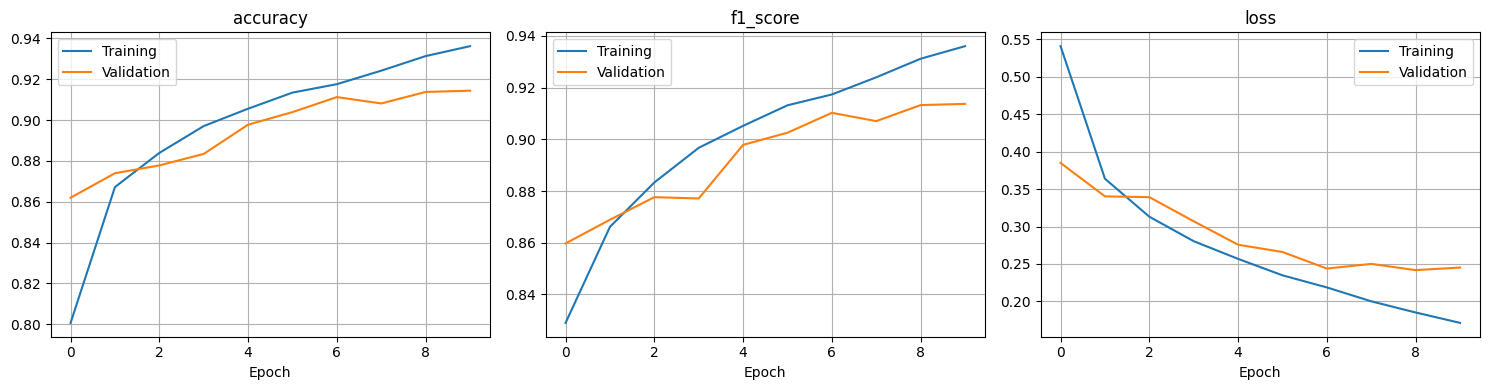

In [149]:
plot_training_history(history_fashion_v1)

## Standard, 2 conv and max. pooling

In [150]:
# test the same model only with maxpoolin instead of average, to extract features better
# build the model
model_v2 = ks.Sequential()

model_v2.add(ks.layers.Conv2D(
    filters=32, kernel_size=(3,3),
    padding='same', name='Conv1',
    activation='relu'
))

model_v2.add(ks.layers.MaxPool2D(
    pool_size =(2,2), strides =(2,2),
    name= 'Pool1'
))

model_v2.add(ks.layers.Conv2D(
    filters=64, kernel_size=(3,3),
    padding='same', name='Conv2',
    activation='relu'
))

model_v2.add(ks.layers.MaxPool2D(
    pool_size=(2,2), strides=(2,2),
    name='Pool2'
))

# flatten before giving to nn
model_v2.add(ks.layers.Flatten())

model_v2.add(ks.layers.Dense(
    units=1024, name='FC1',
    activation='relu'
))

model_v2.add(ks.layers.Dense(
    units=128, name='FC2',
    activation='relu'
))

model_v2.add(ks.layers.Dense(
    units=10, name='Output',
    activation='softmax'
))

# don't need to specify batch size
model_v2.build(input_shape=(None, 28, 28, 1))

model_v2.compile(
    optimizer=ks.optimizers.Adam(),
    loss= ks.losses.CategoricalCrossentropy(),
    metrics= ['accuracy', f1score]
)

model_v2.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 1024)           │     3,212,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,363,594 (12.83 MB)

 Trainable params: 3,363,594 (12.83 MB)

 Non-trainable params: 0 (0.00 B)

In [151]:
history_fashion_v2 = model_v2.fit(X_train, y_train, batch_size=64, epochs=10, validation_split=1/6)

Epoch 1/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8467 - f1_score: 0.8570 - loss: 0.4254 - val_accuracy: 0.8955 - val_f1_score: 0.8964 - val_loss: 0.2864
Epoch 2/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9005 - f1_score: 0.9001 - loss: 0.2689 - val_accuracy: 0.9084 - val_f1_score: 0.9066 - val_loss: 0.2556
Epoch 3/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9169 - f1_score: 0.9166 - loss: 0.2207 - val_accuracy: 0.9076 - val_f1_score: 0.9084 - val_loss: 0.2416
Epoch 4/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9304 - f1_score: 0.9302 - loss: 0.1864 - val_accuracy: 0.9184 - val_f1_score: 0.9177 - val_loss: 0.2267
Epoch 5/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9409 - f1_score: 0.9407 - loss: 0.1575 - val_accuracy: 0.9157 - val_f1_score: 0.9125 - val_loss: 0.2463
Epoch 6/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9502 - f1_score: 0.9501 - loss: 0.1300 - val_accuracy: 0.9268 - val_f1_s

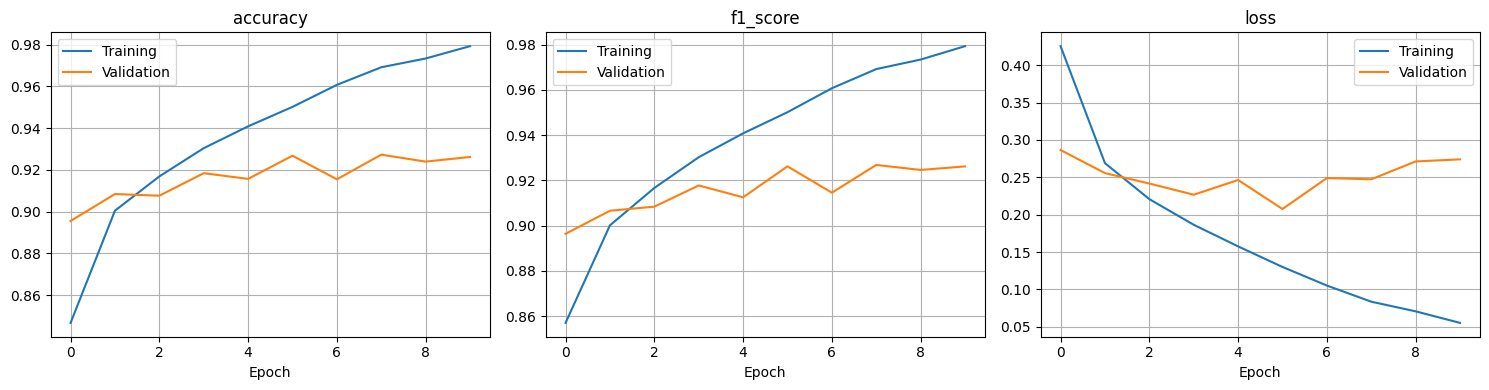

In [152]:
plot_training_history(history_fashion_v2)

## Standard, 4 conv and max. pooling, and 512 neurons in FC1 instead of 1024
### And two conv after each other before pooling

In [153]:
# build the model
model_v3 = ks.Sequential()

model_v3.add(ks.layers.Conv2D(
    filters=16, kernel_size=(3,3),
    padding='same', name='Conv1',
    activation='relu'
))

model_v3.add(ks.layers.MaxPool2D(
    pool_size =(2,2), strides =(1,1),
    name= 'Pool1'
))

model_v3.add(ks.layers.Conv2D(
    filters=32, kernel_size=(3,3),
    padding='same', name='Conv2',
    activation='relu'
))


model_v3.add(ks.layers.Conv2D(
    filters=64, kernel_size=(3,3),
    padding='same', name='Conv3',
    activation='relu'
))


model_v3.add(ks.layers.MaxPool2D(
    pool_size=(2,2), strides=(1,1),
    name='Pool2'
))


model_v3.add(ks.layers.Conv2D(
    filters=128, kernel_size=(3,3),
    padding='same', name='Conv4',
    activation='relu'
))

model_v3.add(ks.layers.MaxPool2D(
    pool_size=(2,2), strides=(2,2),
    name='Pool3'
))

# flatten before giving to nn
model_v3.add(ks.layers.Flatten())

model_v3.add(ks.layers.Dense(
    units=512, name='FC1',
    activation='relu'
))

model_v3.add(ks.layers.Dense(
    units=128, name='FC2',
    activation='relu'
))

model_v3.add(ks.layers.Dense(
    units=10, name='Output',
    activation='softmax'
))

# don't need to specify batch size
model_v3.build(input_shape=(None, 28, 28, 1))

model_v3.compile(
    optimizer=ks.optimizers.Adam(),
    loss= ks.losses.CategoricalCrossentropy(),
    metrics= ['accuracy', f1score]
)

model_v3.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 27, 27, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 27, 27, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 512)            │    11,076,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,240,202 (42.88 MB)

 Trainable params: 11,240,202 (42.88 MB)

 Non-trainable params: 0 (0.00 B)

In [154]:
history_fashion_v3 = model_v3.fit(X_train, y_train, batch_size=64, epochs=10, validation_split=1/6)

Epoch 1/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 123s 158ms/step - accuracy: 0.8547 - f1_score: 0.8661 - loss: 0.4006 - val_accuracy: 0.8983 - val_f1_score: 0.8981 - val_loss: 0.2709
Epoch 2/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 111s 143ms/step - accuracy: 0.9129 - f1_score: 0.9127 - loss: 0.2374 - val_accuracy: 0.9150 - val_f1_score: 0.9154 - val_loss: 0.2325
Epoch 3/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 110s 142ms/step - accuracy: 0.9327 - f1_score: 0.9325 - loss: 0.1811 - val_accuracy: 0.9205 - val_f1_score: 0.9214 - val_loss: 0.2122
Epoch 4/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 105s 136ms/step - accuracy: 0.9474 - f1_score: 0.9473 - loss: 0.1402 - val_accuracy: 0.9275 - val_f1_score: 0.9265 - val_loss: 0.2068
Epoch 5/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 98s 127ms/step - accuracy: 0.9622 - f1_score: 0.9621 - loss: 0.1018 - val_accuracy: 0.9269 - val_f1_score: 0.9265 - val_loss: 0.2380
Epoch 6/10
775/775 ━━━━━━━━━━━━━━━━━━━━ 109s 141ms/step - accuracy: 0.9719 - f1_score: 0.9719 - loss: 0.0768 - val_accuracy: 0.9297

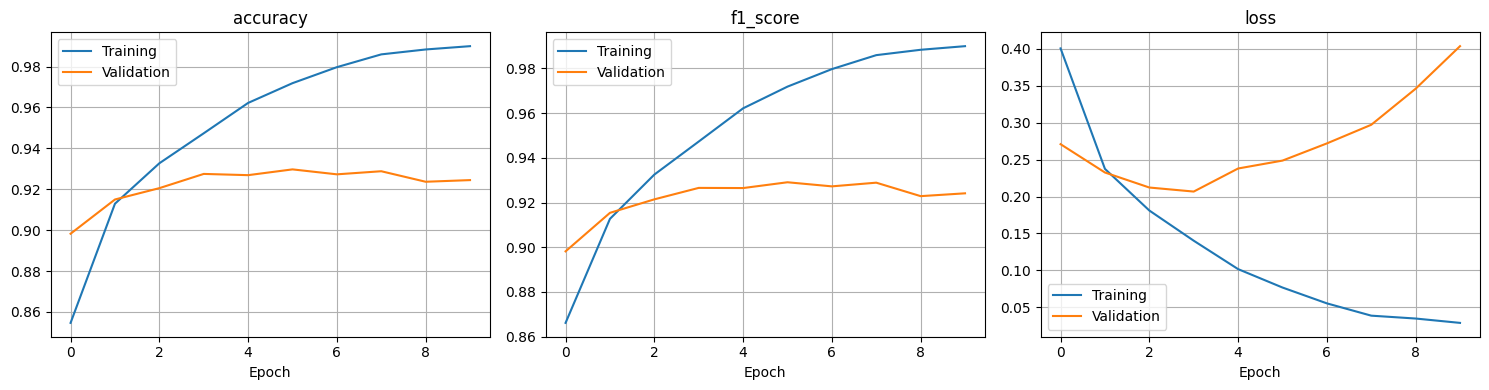

In [155]:
plot_training_history(history_fashion_v3)

# Task 2.5: Fashion-MNIST Discussion

### Task 3.5.1
- Feel Free to experiment on architecture
- Comment on the choice of layers and hyperparameters. 
    - Did you find some different results in changing a hyperparameter or add/remove a layer.
